# CSE620 Mini-Project 2: Simulated Annealing

## Section 0: Setup
---

The following code snippet will ensure that you have all necessary packages in your environment.

In [1]:
!pip install -r requirements.txt

     -------------------------------------- 161.3/161.3 KB 4.9 MB/s eta 0:00:00
     ---------------------------------------- 4.6/4.6 MB 10.9 MB/s eta 0:00:00
     ------------------------------------- 965.4/965.4 KB 12.2 MB/s eta 0:00:00
     -------------------------------------- 138.6/138.6 KB 4.1 MB/s eta 0:00:00
     ------------------------------------- 761.1/761.1 KB 11.9 MB/s eta 0:00:00
     -------------------------------------- 133.5/133.5 KB 4.0 MB/s eta 0:00:00
     ---------------------------------------- 91.1/91.1 KB 5.1 MB/s eta 0:00:00
     ---------------------------------------- 7.2/7.2 MB 22.0 MB/s eta 0:00:00
  Using cached matplotlib_inline-0.1.6-py3-none-any.whl (9.4 kB)
     --------------------------------------- 14.7/14.7 MB 14.2 MB/s eta 0:00:00
     ---------------------------------------- 2.5/2.5 MB 19.8 MB/s eta 0:00:00
     ------------------------------------- 382.8/382.8 KB 12.0 MB/s eta 0:00:00
     -------------------------------------- 252.5/252.5 KB

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Kyle\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python39\\site-packages\\~ywin32_system32\\pythoncom39.dll'
Check the permissions.

You should consider upgrading via the 'C:\Users\Kyle\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip' command.


In [8]:
import json
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

### Problem Setup

The code in this section is the same as what has been seen in the demos. For more details about all individual methods, please refer to the lecture and corresponding demo code.

In [9]:
"""Read input data and define helper functions for visualization."""

# Map services and data available from U.S. Geological Survey, National Geospatial Program.
# Please go to http://www.usgs.gov/visual-id/credit_usgs.html for further information
map = mpimg.imread("include/map.png")  # US States & Capitals map

# Load the US capitals
with open('include/capitals.json', 'r') as capitals_file:
    capitals = json.load(capitals_file)
capitals_list = list(capitals.items())

def show_path(path, starting_city, w=12, h=8):
    """Plot a TSP path overlaid on a map of the US States & their capitals."""
    x, y = list(zip(*path))
    _, (x0, y0) = starting_city
    plt.imshow(map)
    plt.plot(x0, y0, 'y*', markersize=15)  # y* = yellow star for starting point
    plt.plot(x + x[:1], y + y[:1])  # include the starting point at the end of path
    plt.axis("off")
    fig = plt.gcf()
    fig.set_size_inches([w, h])
    
def L2_dist(x, y):
    return ((x[0]-y[0])**2 + (x[1]-y[1])**2)**0.5 
        
def L1_dist(x,y):
    return (abs(x[0]-y[0]) + abs(x[1]-y[1]))

class TravelingSalesmanProblem():
    """Representation of a traveling salesman optimization problem.  The goal
    is to find the shortest path that visits every city in a closed loop path.
    
    Students should only need to implement or modify the successors() and
    get_values() methods.
    
    Parameters
    ----------
    cities : list
        A list of cities specified by a tuple containing the name and the x, y
        location of the city on a grid. e.g., ("Atlanta", (585.6, 376.8))
    
    Attributes
    ----------
    names
    coords
    path : list
        The current path between cities as specified by the order of the city
        tuples in the list.
    """
    def __init__(self, cities, dist_measure=L1_dist):
        self.path = copy.deepcopy(cities)
        self.dist_measure = dist_measure
    
    def copy(self):
        """Return a copy of the current path state."""
        new_tsp = TravelingSalesmanProblem(self.path)
        return new_tsp
    
    @property
    def names(self):
        """Strip and return only the city name from each element of the
        path list. For example,
            [("Atlanta", (585.6, 376.8)), ...] -> ["Atlanta", ...]
        """
        names, _ = zip(*self.path)
        return names
    
    @property
    def coords(self):
        """Strip the city name from each element of the path list and return
        a list of tuples containing only pairs of xy coordinates for the
        cities. For example,
            [("Atlanta", (585.6, 376.8)), ...] -> [(585.6, 376.8), ...]
        """
        _, coords = zip(*self.path)
        return coords
    
    
    def neighborhood(self):
        """Return a list of states in the neighborhood of the current state by
        switching the order in which any adjacent pair of cities is visited.
        
        For example, if the current list of cities (i.e., the path) is [A, B, C, D]
        then the neighbors will include [A, B, D, C], [A, C, B, D], [B, A, C, D],
        and [D, B, C, A]. (The order of successors does not matter.)
        
        In general, a path of N cities will have N neighbors (note that path wraps
        around the end of the list between the first and last cities).

        Returns
        -------
        list<Problem>
            A list of TravelingSalesmanProblem instances initialized with their list
            of cities set to one of the neighboring permutations of cities in the
            present state
        """
        neighbors = []
        for i in range(len(self.path)-1):
            new_path = self.copy()
            new_path.path[i], new_path.path[i+1] = new_path.path[i+1], new_path.path[i] # Swap two non-adjacent edges
            neighbors.append(new_path)
            
        last_path = self.copy()
        last_path.path[0], last_path.path[-1] = last_path.path[-1], last_path.path[0]
        neighbors.append(last_path)
        
        return neighbors 
    
        
    def evaluate(self):
        """Calculate the total length of the closed-circuit path of the current
        state by summing the distance between every pair of adjacent cities.  Since
        the default simulated annealing algorithm seeks to maximize the objective
        function, return -1x the path length. (Multiplying by -1 makes the smallest
        path the smallest negative number, which is the maximum value.)
        
        Returns
        -------
        float
            A floating point value with the total cost of the path given by visiting
            the cities in the order according to the self.cities list
        
        Notes
        -----
            (1) Remember to include the edge from the last city back to the
            first city
            
            (2) Remember to multiply the path length by -1 so that simulated
            annealing finds the shortest path
        """
        
        
        length = 0
        coords = self.coords
        for i in range(len(coords)-1):
            length += np.abs(self.dist_measure(coords[i], coords[i+1]))
            
        length += np.abs(self.dist_measure(coords[0], coords[-1])) # Return to the initial city
        return length
    
    
def generate_TSP(num_cities, random_state=None):
    """Method to randomly generate the cities for a TSP problem instance"""
    rand_gen = np.random.default_rng(random_state)


    capitals_idx = rand_gen.choice(
        list(range(0, len(capitals_list))),
             size=(num_cities,),
             replace=False
             )

    return np.array(capitals_list, dtype="object")[capitals_idx].tolist()

### Optimizer Setup

Again, code in this section is the same as in the demo lectures. Please just run the code here to use in the later sections.

In [10]:
class Schedule():
    def __init__(self, method="exponential", alpha=0.95, starting_temp=100):
        self.method = method
        self.alpha = alpha
        self.T_0 = starting_temp

    def cool(self, k):
        """
        Implements several cooling methods using format from:
        http://what-when-how.com/artificial-intelligence/a-comparison-of-cooling-schedules-for-simulated-annealing-artificial-intelligence/
        """
        if self.method == "exponential":
            # Assumes alpha is a constant 0.8 <= alpha <= 0.9
            return self.T_0*(self.alpha**k)
        
        if self.method == "logarithmic":
            # Assumes alpha is a constant greater than 1
            return  self.T_0/(1 + self.alpha * np.log(1+k))
        
        if self.method == "linear":
            # Assumes alpha is a constant greater than zero
            return self.T_0/(1+self.alpha*k)
        
        else:
            raise NotImplementedError(f"There is no cooling schedule matching {self.method}")

def simulated_annealing(problem, cooling_schedule, stop_temp=1e-5, max_iter=np.inf, random_state=None, verbose=True):
    """The simulated annealing algorithm, a version of stochastic hill climbing
    where some downhill moves are allowed. Downhill moves are accepted readily
    early in the annealing schedule and then less often as time goes on. The
    schedule input determines the value of the temperature T as a function of
    time.
    
    Parameters
    ----------
    problem : Problem
        An optimization problem, already initialized to a random starting state.
        The Problem class interface must implement a callable method
        "neighborhood()" which returns states in the neighborhood of the current
        state, and a callable function "evaluate()" which returns a fitness
        score for the state. (See the `TravelingSalesmanProblem` class for more details.)
        
    cooling_schedule : Schedule
        Instance of Schedule class initialized containing starting temp, alpha, and specified
        cooling method to use.

    stop_criteria : float
        Threshold for the temperature to determine when to stop the search.
        
    random_state : int
        The seed for the pseudorandom number generator. Passing "None" or no argument
        will result in wholely random behaviour each run. Passing any other integer value
        will produce the same behaviour and final convergence each run. 
        
    Returns
    -------
    Problem
        An approximate *best* found solution state of the optimization problem
        
    See Also
    --------
    Adapted (with modifications) from AIMA simulated_annealing() pseudocode
        https://github.com/aimacode/aima-pseudocode/blob/master/md/Simulated-Annealing.md
    """
    rand_gen = np.random.default_rng(random_state) # Makes our results reproducible with the same seed
    
    current = problem
    best_solution = current
    best_cost = current.evaluate()
    
    T_k = cooling_schedule.T_0
    k = 0
    
    while k < max_iter and T_k > stop_temp:
        T_k = cooling_schedule.cool(k)
        
        next_state = rand_gen.choice(current.neighborhood())
        
        # Find costs for determining the Δ
        current_cost = current.evaluate()
        next_cost = next_state.evaluate()
        
        if next_cost < current_cost: # Case where f(j) <= f(i) 
            current = next_state
            
            # If this is the best move we have found so far, record it
            if next_cost < best_cost:
                best_solution = next_state
                best_cost = next_cost
            
        else:
            # With some probability, accept a worse move
            prob = np.exp((current_cost - next_cost)/T_k)
            R = rand_gen.uniform(0,1)
            if prob > R:
                current = next_state
        
        k += 1
    
    if verbose:
        print(f"Terminated with temperature T={T_k:.2g}\nAt iteration #{k:,}.")
        
    return best_solution

# Hill Climbing algorithm
def hill_climbing(problem, max_iter=1e10, min_delta=0):
    iterations = 0
    current = problem # FYI, current will always be the best path we have seen (greedy)
    delta = np.inf
    
    # While there is still a notable change from the last state to the next, repeat the above from the new state
    while delta > min_delta and iterations < max_iter:
        neighborhood = current.neighborhood()
        best_neighbor_idx = np.argmin([x.evaluate() for x in neighborhood]) # Find the closest neighbour
        next_state = neighborhood[best_neighbor_idx] # Move to the next state
        delta = current.evaluate() - next_state.evaluate() 
        current = next_state
        iterations += 1
    return current

## Section 1
---

In this section, you will experiment with the commonly used exponential decay cooling schedule. For quick reference, cooling via exponential decay is calculated as:

$T_k \leftarrow T_0*\alpha*k$

Where $T_0$ is the starting temp, $\alpha$ is the decay rate, and $T_k$ is the temperature at time step $k$. This is also synonymous with

$T_k \leftarrow T_{k-1}*\alpha$

as seen in the reading assignments.

In [11]:
capitals_subset = generate_TSP(num_cities=15, random_state=254)
" → ".join([city[0] for city in capitals_subset])

'Phoenix → Boston → Saint Paul → Little Rock → Nashville → Des Moines → Boise → Baton Rouge → Harrisburg → Atlanta → Salt Lake City → Denver → Montgomery → Lansing → Richmond'

Initial path value: 5047.20


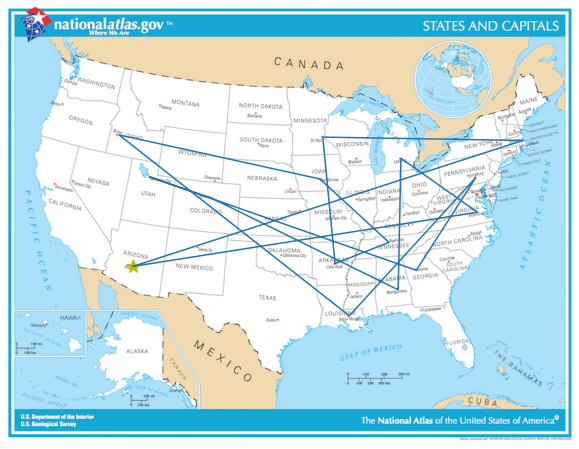

In [12]:
# Create the problem instance and plot the initial state
capitals_tsp = TravelingSalesmanProblem(capitals_subset)
starting_city = capitals_subset[0]
print("Initial path value: {:.2f}".format(capitals_tsp.evaluate()))
show_path(capitals_tsp.coords, starting_city)

In [13]:
# Set the decay rate (alpha) and initial temperature parameters, then run simulated annealing to solve the TSP
avg_time = 0
schedule = Schedule(method="exponential",
                    alpha=0.95, # Vary this!
                    starting_temp=4000) # Vary this!

for _ in range(10):
    start = time.perf_counter()
    result = simulated_annealing(capitals_tsp, schedule, max_iter=np.inf, random_state=192, verbose=False)
    avg_time += ((time.perf_counter()-start)*1e3)/10 # Record the time in milliseconds

print("Best path length: {:.2f}".format(result.evaluate()))
print("Average time taken: {:.2f}".format(avg_time))

Best path length: 2504.80
Average time taken: 1064.03


## Section 2
---

In this section, you will use linear multiplicative decay to compare its performance against exponential decay. For quick reference, cooling via linear decay is calculated as:

$T_k \leftarrow \frac{T_0}{1+\alpha*k}$

Where $T_0$ is the starting temp, $\alpha$ is the decay rate, and $T_k$ is the temperature at time step $k$.

In [14]:
# Set the decay rate (alpha) and initial temperature parameters, then run simulated annealing to solve the TSP
avg_time = 0
schedule = Schedule(method="linear",
                    alpha=0.95, # Vary this!
                    starting_temp=4000) # Vary this!

for _ in range(10):
    start = time.perf_counter()
    result = simulated_annealing(capitals_tsp, schedule, stop_temp=1, max_iter=1e10, random_state=192, verbose=False)
    avg_time += ((time.perf_counter()-start)*1e3)/10 # Record the time in milliseconds

print("Best path length: {:.2f}".format(result.evaluate()))
print("Average time taken: {:.2f}".format(avg_time))

Best path length: 2477.60
Average time taken: 5414.74


## Section 3

Here you will experiment with the best found parameters for simulated annealing against hill climbing as the size of the problem grows.

In [15]:
capitals_subset = generate_TSP(num_cities=30,    # Vary the number of cities here
                               random_state=254)


print(" → ".join([city[0] for city in capitals_subset]))
capitals_tsp = TravelingSalesmanProblem(capitals_subset)
starting_city = capitals_subset[0]
print("Initial path value: {:.2f}".format(capitals_tsp.evaluate()))

Columbia → Saint Paul → Albany → Richmond → Hartford → Nashville → Baton Rouge → Oklahoma City → Trenton → Little Rock → Sacramento → Salt Lake City → Atlanta → Harrisburg → Jackson → Columbus → Boston → Denver → Phoenix → Boise → Austin → Indianapolis → Des Moines → Madison → Salem → Raleigh → Tallahassee → Providence → Lansing → Montgomery
Initial path value: 8790.40


Then perform simulated annealing using whatever best parameters (cooling schedule, starting temp, alpha) were found from the previous experiments:

In [16]:
avg_time = 0
schedule = Schedule(method="exponential", # Change this to your best found value!
                    alpha=0.95, # Change this to your best found value!
                    starting_temp=4000) # Change this to your best found value!

for _ in range(10):
    start = time.perf_counter()
    result = simulated_annealing(capitals_tsp, schedule, max_iter=np.inf, random_state=192, verbose=False)
    avg_time += ((time.perf_counter()-start)*1e3)/10 # Record the time in milliseconds

print("Best path length: {:.2f}".format(result.evaluate()))
print("Average time taken: {:.2f}".format(avg_time))

Best path length: 5764.00
Average time taken: 2393.35


Then perform hill climbing on the same problem instance:

In [17]:
avg_time = 0

for _ in range(10):
    start = time.perf_counter()
    result = hill_climbing(capitals_tsp)
    avg_time += ((time.perf_counter()-start)*1e3)/10 # Record the time in milliseconds

print("Best path length: {:.2f}".format(result.evaluate()))
print("Average time taken: {:.2f}".format(avg_time))

Best path length: 7619.20
Average time taken: 68.74


## Section 4

In [18]:
capitals_subset = generate_TSP(num_cities=5,    # Vary the number of cities here
                               random_state=254)


print(" → ".join([city[0] for city in capitals_subset]))
capitals_tsp = TravelingSalesmanProblem(capitals_subset)
starting_city = capitals_subset[0]
print("Initial path value: {:.2f}".format(capitals_tsp.evaluate()))

Richmond → Boston → Providence → Phoenix → Lansing
Initial path value: 1632.80


In [19]:
avg_time = 0
schedule = Schedule(method="exponential", # Use your best found parameters here!
                    alpha=0.95, 
                    starting_temp=1e5)

for _ in range(10):
    start = time.perf_counter()
    result = simulated_annealing(capitals_tsp, schedule, max_iter=5e3, random_state=192, verbose=False)
    avg_time += ((time.perf_counter()-start)*1e3)/10 # Record the time in milliseconds

print("Best path length: {:.2f}".format(result.evaluate()))
print("Average time taken: {:.2f}".format(avg_time))

Best path length: 1478.40
Average time taken: 116.04


In [20]:
avg_time = 0

for _ in range(10):
    start = time.perf_counter()
    result = hill_climbing(capitals_tsp)
    avg_time += ((time.perf_counter()-start)*1e3)/10 # Record the time in milliseconds

print("Best path length: {:.2f}".format(result.evaluate()))
print("Average time taken: {:.2f}".format(avg_time))

Best path length: 1478.40
Average time taken: 0.94
